# An Exercise in Customizing SeQUeNCe
#### By Robert Hayek and the SeQueNCe Development Team at Argonne National Laboratory

## The Basics
SeQueNCe is composed of 6 modular components. As SeQUeNCe is developed, registry patterns have been added to the network manager, entanglement manager, and quantum manager. This allows you to swap out components on-the-fly, at runtime. For example, you can create multiple variations of an entanglement generation protocol and test each in a single simulation run, all without modifying the source code directly.

In short, we take advantage of the [registry/factory design pattern](https://en.wikipedia.org/wiki/Factory_method_pattern) to allow you to swap out components of SeQueNCe or simulate custom modules without modifying source code.

![image.png](sequence_arch.png)


In this exercise we will go through the basics of how to take advantage of SeQUeNCe's customizability. First you will change the entanglement generation protocol, then you will create a new topology with our NetworkX plugin and simulate using the Single-heralded entanglement generation protocol.

Although I could provide config files for the topology, we will take advantage of a new SeQUeNCe feature that creates the topology object on-the-fly.
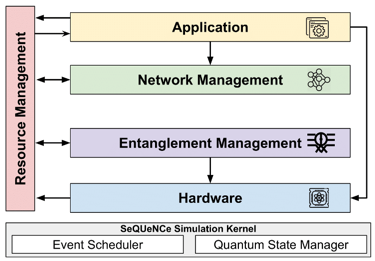

### Imports
These are all of the imports needed for this tutorial. Future development of SeQUeNCe aims to expose only one import for the same functionality.

In [3]:
import networkx as nx
from sequence.app.request_app import RequestApp
from sequence.constants import KET_VECTOR_FORMALISM, SINGLE_HERALDED, BARRET_KOK, BELL_DIAGONAL_STATE_FORMALISM
from sequence.entanglement_management.generation import EntanglementGenerationA, EntanglementGenerationB
from sequence.entanglement_management.swapping import EntanglementSwappingA, EntanglementSwappingB
from sequence.kernel.quantum_manager import QuantumManager as qm
from sequence.topology.router_net_topo import RouterNetTopo
from sequence.utils import metrics
from sequence.utils.graphs import build_linear
from sequence.utils.nx_converter import generate_config

import warnings

warnings.filterwarnings("ignore")

/Users/rhayek/Documents/qce2026/.venv/lib/python3.14/site-packages/sequence/entanglement_management/purification/bbpssw_bds.py:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  both solutions to the equation, i.e. p = (1 \pm \sqrt{2q-1})/2, are valid (between 0 and 1);


### Topology Templates
The topology generator will take care of creating the quantum nodes, bell-state measurement nodes, and links between each device. To set some desired parameters SeQUeNCe can take in template objects in the form of .json/dict objects. Here we import two templates: one for the Ket formalism and one for the Bell-Diagonal formalism.

In [4]:
bds_template = {
  "router_template": {
    "MemoryArray": {
      "frequency": 200000000.0,
      "coherence_time": 2,
      "efficiency": 1,
      "fidelity": 0.9
    }
  },
  "bsm_template": {
    "encoding_type": "single_heralded",
    "SingleHeraldedBSM": {
      "detectors": [
        {
          "efficiency": 1,
          "dark_count": 0,
          "time_resolution": 6,
          "count_rate": 100000000000.0
        },
        {
          "efficiency": 1,
          "dark_count": 0,
          "time_resolution": 6,
          "count_rate": 100000000000.0
        }
      ]
    }
  }
}

ket_template = {
  "router_template": {
    "MemoryArray": {
      "frequency": 200000000.0,
      "coherence_time": 2,
      "efficiency": 1,
      "fidelity": 0.9
    }
  },
  "bsm_template": {
    "encoding_type": "single_atom",
    "SingleAtomBSM": {
      "detectors": [
        {
          "efficiency": 1,
          "dark_count": 0,
          "time_resolution": 6,
          "count_rate": 100000000000.0
        },
        {
          "efficiency": 1,
          "dark_count": 0,
          "time_resolution": 6,
          "count_rate": 100000000000.0
        }
      ]
    }
  }
}

### Experiment Runner
This is the experiment runner. It is agnostics SeQUeNCe module configurations. The main function is to initialize a  `RequestApp` on each quantum node in the topology, and start entanglement generation between the source and destination nodes. Additionally, we will enable metrics that we would like to capture.

In [12]:
def run_simulation(topo, src_name, dst_name) -> float:

    PS_PER_SECOND = 1e12
    REQUEST_START = 1 * PS_PER_SECOND
    REQUEST_END = 5 * PS_PER_SECOND
    tl = topo.get_timeline()
    metrics.register_time_provider(tl)
    metrics.enable([metrics.EG_METRIC])

    name_to_apps = {}
    for router in topo.get_nodes_by_type(RouterNetTopo.QUANTUM_ROUTER):
        app = RequestApp(router)
        name_to_apps[router.name] = app
    name_to_apps[src_name].start(dst_name, start_t=REQUEST_START, end_t=REQUEST_END, memo_size=5, fidelity=0.9)

    tl.init()
    tl.run()
    results = metrics.collect_trial_metrics(src_name)
    results['throughput'] = name_to_apps[src_name].get_throughput()
    return results

### Create the NetworkX graph object to use for the simulation.
To keep it simple we will configure two nodes seperated by 1km with attenuation of 0.0002 dB/m

In [6]:
g = build_linear(2, 1, 0.0002)

In [7]:
EntanglementGenerationA.set_global_type(BARRET_KOK)
EntanglementGenerationB.set_global_type(BARRET_KOK)
qm.set_global_manager_formalism(KET_VECTOR_FORMALISM)

ket_config, _ = generate_config(g, cc_delay=1, formalism=KET_VECTOR_FORMALISM, node_template=ket_template)

topo = RouterNetTopo(ket_config)
bk_result = run_simulation(topo, 'router_0', 'router_1')

In [8]:
EntanglementGenerationA.set_global_type(SINGLE_HERALDED)
EntanglementGenerationB.set_global_type(SINGLE_HERALDED)
qm.set_global_manager_formalism(BELL_DIAGONAL_STATE_FORMALISM)

bds_config, _ = generate_config(g, cc_delay=1, formalism=BELL_DIAGONAL_STATE_FORMALISM, node_template=bds_template)
topo = RouterNetTopo(bds_config)
sh_result = run_simulation(topo, 'router_0', 'router_1')

In [9]:
print(f'Metrics Barret-Kok:\n {bk_result}')
print(f'Metrics Single-Heralded:\n {sh_result}')

Metrics Barret-Kok:
 {'eg_failures': 1669, 'eg_success': 1696, 'eg_success_rate': 0.5040118870728083, 'throughput': 424.0}
Metrics Single-Heralded:
 {'eg_failures': 4307, 'eg_success': 4053, 'eg_success_rate': 0.4848086124401914, 'throughput': 589.25}


### Custom Topologies
In SeQUeNCe you can create any custom topology using the NetworkX to SeQUeNCe converter. Here you will implement a custom graph, either using one provided by NetworkX or create a custom graph using the NetworkX library.

In [10]:
diamond_graph: nx.Graph = nx.diamond_graph()
nx.set_edge_attributes(diamond_graph, 1, name='length')
nx.set_edge_attributes(diamond_graph, 0.0002, name='attenuation')

bds_diamond_graph_config, _ = generate_config(diamond_graph, cc_delay=1, formalism=BELL_DIAGONAL_STATE_FORMALISM, node_template=bds_template)

Now we have the ability to run the simulation on an arbitrary graph. Additionally, swapping is now enabled to ensure that end-to-end entanglement can be generated over hops.

In [11]:
EntanglementGenerationA.set_global_type(SINGLE_HERALDED)
EntanglementGenerationB.set_global_type(SINGLE_HERALDED)
EntanglementSwappingA.set_formalism(BELL_DIAGONAL_STATE_FORMALISM) # Enable swapping as there are now hops
EntanglementSwappingB.set_formalism(BELL_DIAGONAL_STATE_FORMALISM)
qm.set_global_manager_formalism(BELL_DIAGONAL_STATE_FORMALISM)

diamond_graph_topo = RouterNetTopo(bds_diamond_graph_config)
d_graph_result = run_simulation(diamond_graph_topo, 'router_1', 'router_3')
print('Metrics with Single-Heralded on the Diamond Graph')
print(d_graph_result)

Metrics with Single-Heralded on the Diamond Graph
{'eg_failures': 6900, 'eg_success': 6455, 'eg_success_rate': 0.48333957319356047, 'throughput': 600.5}
